In [2]:
!pip install umap-learn hdbscan

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/670.6 kB ? eta -:--:--
   ---------------------------------------- 670.6/670.6 kB 6.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -------------------------- ------------- 1.8/2.7 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 8.0 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.1 MB 7.6 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/38.1 MB 7.9 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/38.1 MB 7.9 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/38.1 MB 7.9 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/38.1 MB 7.9 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/38.1 MB 7.9 MB/s eta 0:00:05
   --- ----------------------------------

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics.pairwise import cosine_similarity

import umap
import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Painel-Projetos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = pd.read_excel("dataset_cluster_pronto.xlsx")

df.shape
df.head()

,GUID,Nome_Projeto,Setor do projeto (de acordo com a classificação da PPI),Subsetor do projeto (de acordo com a classificação da PPI),Quem será a Autoridade Contratante?,Quem irá estruturar o projeto?,Qual é o modelo de PPP?,Qual é o estágio atual do projeto?,Qual é o valor total do contrato?,Qual é o valor total do investimento?,Qual é o valor total da receita?,Qual é o valor total da contrapartida do governo?,Qual é o valor total da contrapartida do parceiro privado?,Data de qualificação em PPI,maturidade_ord,anos_desde_PPI,flag_contrap_publica,flag_contrap_privada
0,0132e2be-059a-41e0-b2f4-c1a822c0a5c1,Ilumina&#231;&#227;o P&#250;blica - Lageado (RS),Urban Services,Street Lighting,município,CAIXA,NaN,NaN,In Progress,NaN,Administrative concession (Government funded PPP),NaN,NaN,2019-08-21,NaN,6.654795,0.0,0.0
1,01fb8247-91ec-4631-bf1f-3da9fa6822d6,BR-116/324/BA - Rota 2 de julho,Transport,Highway,Ministério dos Transportes,INFRA,No,Largest discount,In Progress,"Resolução CPPI 342, de 1º de julho de 2025",Administrative concession (Government funded PPP),"Decreto 12.684, de 20 de outubro de 2025",29ª REUNIÃO,2025-10-20,NaN,0.484932,1.0,1.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Resolução CPPI 346, de 04 de setembro de 2025",NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,022ea245-c8f4-440a-9a1b-2aa0e2f523fd,Apoio &#224; Visita&#231;&#227;o e &#224; Cons...,Other,Other,ICMBio,BNDES,No,Largest grant,In Progress,"Resolução CPPI n° 328, de 25 de março de 2025",NaN,"Decreto nº 12.602, de28 de agosto de 2025",28ª REUNIÃO,2025-03-25,NaN,1.057534,1.0,1.0
4,03175202-1983-4ce9-9425-f8271bf2e138,Canal de Acesso Aquaviário do Porto de Rio Gra...,Transport,Seaport,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,4.641096,0.0,0.0


In [6]:
categorical_cols = [
    "Setor do projeto (de acordo com a classificação da PPI)",
    "Subsetor do projeto (de acordo com a classificação da PPI)",
    "Quem será a Autoridade Contratante?",
    "Quem irá estruturar o projeto?",
    "Qual é o modelo de PPP?"
]

numeric_cols = [
    "Qual é o valor total do contrato?",
    "Qual é o valor total do investimento?",
    "Qual é o valor total da receita?",
    "maturidade_ord",
    "anos_desde_PPI",
    "flag_contrap_publica",
    "flag_contrap_privada"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [12]:
# Copiar dataset
df_model = df.copy()

# Remover colunas que não entram no modelo
df_model = df_model.drop(columns=[
    "GUID",
    "Nome_Projeto",
    "Qual é o estágio atual do projeto?"
], errors="ignore")

# Forçar conversão numérica segura
for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model[numeric_cols] = df_model[numeric_cols].fillna(
    df_model[numeric_cols].median()
)

#  CORREÇÃO-CHAVE: categóricas como string
for col in categorical_cols:
    df_model[col] = df_model[col].astype(str).replace("nan", "Missing")

# Transformação
X = preprocessor.fit_transform(df_model)

X.shape

c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Painel-Projetos\.venv\Lib\site-packages\sklearn\preprocessing\_data.py:1705: RuntimeWarning: All-NaN slice encountered
  self.center_ = np.nanmedian(X, axis=0)
c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Painel-Projetos\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


(374, 131)

In [15]:
import numpy as np

X_dense = X.toarray() if hasattr(X, "toarray") else X
X_dense = np.nan_to_num(X_dense)

similarity_matrix = cosine_similarity(X_dense)
similarity_matrix.shape

(374, 374)

In [17]:
import numpy as np
import umap

# Converter para array denso, se necessário
X_dense = X.toarray() if hasattr(X, "toarray") else X

# Eliminar qualquer NaN residual
X_dense = np.nan_to_num(X_dense)

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.15,
    metric="cosine",
    random_state=42
)

embedding = reducer.fit_transform(X_dense)

embedding.shape

c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Painel-Projetos\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(374, 2)

In [18]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean"
)

clusters = clusterer.fit_predict(embedding)
df["cluster"] = clusters

df["cluster"].value_counts()

cluster
 0     107
 1      34
 6      29
 8      27
 12     27
 7      22
 10     22
 9      20
 11     17
 4      17
 5      17
 3      14
 2      11
-1      10
Name: count, dtype: int64

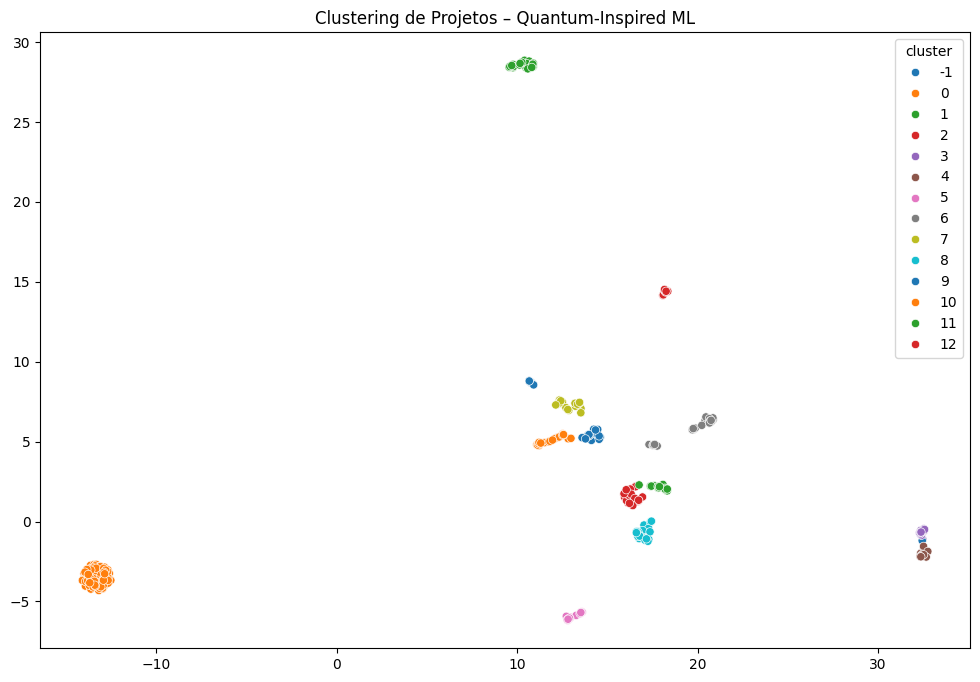

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=df["cluster"],
    palette="tab10",
    legend="full"
)

plt.title("Clustering de Projetos – Quantum‑Inspired ML")
plt.show()

In [20]:
np.isnan(embedding).sum()

np.int64(0)

In [23]:
# Selecionar apenas colunas realmente numéricas
numeric_for_profile = df.select_dtypes(include=["int64", "float64"]).columns

cluster_numeric_profile = (
    df.groupby("cluster")[numeric_for_profile]
      .median()
      .round(2)
)

cluster_numeric_profile

,maturidade_ord,anos_desde_PPI,flag_contrap_publica,flag_contrap_privada,cluster
cluster,,,,,
-1,NaN,4.33,1.0,1.0,-1.0
0,NaN,NaN,NaN,NaN,0.0
1,NaN,6.65,0.0,0.0,1.0
2,NaN,6.39,0.0,0.0,2.0
3,NaN,6.65,1.0,1.0,3.0
4,NaN,6.94,1.0,1.0,4.0
5,NaN,6.94,1.0,0.0,5.0
6,NaN,4.64,0.0,0.0,6.0
7,NaN,5.50,1.0,1.0,7.0


In [29]:
# Garantir que colunas usadas na agregação sejam realmente numéricas
cols_to_numeric = [
    "anos_desde_PPI",
    "Qual é o valor total do investimento?",
    "maturidade_ord",
    "flag_contrap_publica",
    "flag_contrap_privada"
]

for col in cols_to_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [30]:
cluster_summary = (
    df.groupby("cluster")
      .agg(
          projetos=("Nome_Projeto", "count"),
          idade_mediana=("anos_desde_PPI", "median"),
          investimento_medio=("Qual é o valor total do investimento?", "median"),
          maturidade_media=("maturidade_ord", "median"),
          contrap_publica_pct=("flag_contrap_publica", "mean"),
          contrap_privada_pct=("flag_contrap_privada", "mean"),
      )
      .round(2)
)

cluster_summary

,projetos,idade_mediana,investimento_medio,maturidade_media,contrap_publica_pct,contrap_privada_pct
cluster,,,,,,
-1,10,4.33,NaN,NaN,1.00,1.00
0,0,NaN,NaN,NaN,NaN,NaN
1,34,6.65,NaN,NaN,0.00,0.00
2,11,6.39,NaN,NaN,0.00,0.00
3,14,6.65,NaN,NaN,0.93,0.93
4,17,6.94,NaN,NaN,1.00,1.00
5,17,6.94,NaN,NaN,0.94,0.35
6,29,4.64,NaN,NaN,0.21,0.28
7,22,5.50,NaN,NaN,0.91,0.91


In [27]:
pd.crosstab(
    df["cluster"],
    df["Setor do projeto (de acordo com a classificação da PPI)"],
    normalize="index"
).round(2)


Setor do projeto (de acordo com a classificação da PPI),Energy,Other,Social Infrastructure,Transport,Urban Services,Water & Waste
cluster,,,,,,
-1,0.00,0.00,0.00,0.0,0.00,1.00
1,0.00,0.00,0.00,0.0,1.00,0.00
2,0.00,0.00,0.82,0.0,0.00,0.18
3,0.00,0.00,0.00,0.0,0.00,1.00
4,0.00,0.00,0.00,0.0,0.00,1.00
5,0.00,0.00,0.00,0.0,1.00,0.00
6,0.03,0.07,0.00,0.9,0.00,0.00
7,0.05,0.95,0.00,0.0,0.00,0.00
8,0.00,0.00,0.00,1.0,0.00,0.00


In [25]:
pd.crosstab(
    df["cluster"],
    df["Quem irá estruturar o projeto?"],
    normalize="index"
).round(2)


Quem irá estruturar o projeto?,BNDES,CAIXA,FDIRS,FEP CAIXA,INFRA,Other
cluster,,,,,,
-1,0.20,0.00,0.2,0.00,0.00,0.60
1,0.00,1.00,0.0,0.00,0.00,0.00
3,0.93,0.07,0.0,0.00,0.00,0.00
4,0.00,0.06,0.0,0.94,0.00,0.00
5,0.00,0.00,0.0,0.94,0.00,0.06
6,0.50,0.00,0.0,0.00,0.00,0.50
7,0.64,0.00,0.0,0.00,0.00,0.36
8,0.09,0.00,0.0,0.00,0.86,0.05
9,0.75,0.15,0.0,0.05,0.00,0.05


In [32]:
import html

# Corrigir encoding HTML em TODAS as colunas de texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(
        lambda x: html.unescape(x) if isinstance(x, str) else x
    )

C:\Users\carlos.ramos\AppData\Local\Temp\ipykernel_13672\3620395558.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [37]:
cluster_names = {
    0: "Projetos padrão replicáveis",
    1: "Projetos médios com boa maturidade",
    2: "Projetos pequenos e altamente específicos",
    3: "Projetos antigos com baixa maturidade",
    4: "Projetos com forte dependência pública",
    5: "Projetos com estrutura institucional complexa",
    6: "Projetos estruturados por grandes agentes",
    7: "Projetos setoriais concentrados",
    8: "Projetos de médio porte e execução lenta",
    9: "Projetos novos em aceleração",
    10: "Projetos grandes com risco institucional",
    11: "Projetos atípicos setorialmente",
    12: "Projetos de alto valor e longa maturação",
    -1: "Outliers – casos excepcionais"
}

df["cluster_nome"] = df["cluster"].map(cluster_names)

df[["Nome_Projeto", "cluster", "cluster_nome"]].head(10)

,Nome_Projeto,cluster,cluster_nome
0,Iluminação Pública - Lageado (RS),1,Projetos médios com boa maturidade
1,BR-116/324/BA - Rota 2 de julho,11,Projetos atípicos setorialmente
2,NaN,0,Projetos padrão replicáveis
3,Apoio à Visitação e à Conservação de área de F...,9,Projetos novos em aceleração
4,Canal de Acesso Aquaviário do Porto de Rio Gra...,6,Projetos estruturados por grandes agentes
5,EF-277 - Estrada de Ferro Paraná Oeste - Ferro...,6,Projetos estruturados por grandes agentes
6,Iluminação Pública - Barra dos Coqueiros (SE),1,Projetos médios com boa maturidade
7,Iluminação Pública - Novo Hamburgo (RS),1,Projetos médios com boa maturidade
8,POA26 - Terminal de cargas multipropósito no P...,11,Projetos atípicos setorialmente
9,TGSFS- Terminal de granel vegetal no Porto de...,8,Projetos de médio porte e execução lenta


In [70]:
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 80)

df_vis = (
    df[["Nome_Projeto", "cluster", "cluster_nome"]]
    .sort_values(["cluster", "Nome_Projeto"])
    .reset_index(drop=True)
)

df_vis

,Nome_Projeto,cluster,cluster_nome
0,Baixo Acaraú/CE,-1,Outliers – casos excepcionais
1,Etapas 3 e 4 do Projeto de Irrigação Jaíba/MG,-1,Outliers – casos excepcionais
2,Irrigação da Zona de Influência do Canal Adutor do Sertão Alagoano,-1,Outliers – casos excepcionais
3,Platôs de Guadalupe/PI,-1,Outliers – casos excepcionais
4,Projeto Pontal - Mancha 20 e Mancha 23,-1,Outliers – casos excepcionais
...,...,...,...
369,Rodovias de Santa Catarina,12,Projetos de alto valor e longa maturação
370,Rumo Malha Sul - Corredor Mercosul,12,Projetos de alto valor e longa maturação
371,Rumo Malha Sul - Corredor Paraná-Santa Catarina,12,Projetos de alto valor e longa maturação
372,Rumo Malha Sul - Corredor Rio Grande,12,Projetos de alto valor e longa maturação


In [72]:
df_vis.to_excel(
    "projetos_por_cluster.xlsx",
    index=False
)


In [39]:
!pip install pennylane


  Using cached pennylane-0.44.1-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached rustworkx-0.17.1-cp39-abi3-win_amd64.whl.metadata (10 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached autoray-0.8.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached cachetools-7.0.5-py3-none-any.whl.metadata (5.6 kB)
  Using cached pennylane_lightning-0.44.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tomlkit-0.14.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached diastatic_malt-2.15.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached scipy_openblas32-0.3.3

In [40]:
# escolher um projeto real
row = df[df["cluster"] == 1].iloc[0]

row[["Nome_Projeto", "anos_desde_PPI", "Qual é o valor total do investimento?"]]

Nome_Projeto                             Iluminação Pública - Lageado (RS)
anos_desde_PPI                                                    6.654795
Qual é o valor total do investimento?                                  NaN
Name: 0, dtype: object

In [42]:
# normalização min-max baseada na base inteira
anos_min, anos_max = df["anos_desde_PPI"].min(), df["anos_desde_PPI"].max()
inv_min, inv_max = (
    df["Qual é o valor total do investimento?"].min(),
    df["Qual é o valor total do investimento?"].max()
)

x_norm_1 = (row["anos_desde_PPI"] - anos_min) / (anos_max - anos_min)
x_norm_2 = (row["Qual é o valor total do investimento?"] - inv_min) / (inv_max - inv_min)

x_norm_1, x_norm_2


(np.float64(0.6895453229597498), np.float64(nan))

In [43]:
import numpy as np

theta = 2 * np.pi * x_norm_1   # codifica tempo no PPI
phi   = 2 * np.pi * x_norm_2   # codifica investimento

theta, phi


(np.float64(4.3325410418551025), np.float64(nan))

In [44]:
import pennylane as qml

dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def quantum_embedding(theta, phi):
    qml.RY(theta, wires=0)
    qml.RZ(phi, wires=0)
    return qml.state()

In [45]:
state = quantum_embedding(theta, phi)
state

array([nan+nanj, nan+nanj])

In [47]:
row["anos_desde_PPI"], anos_min, anos_max


(np.float64(6.654794521), np.float64(0.131506849), np.float64(9.591780822))

In [48]:
row["Qual é o valor total do investimento?"], inv_min, inv_max

(np.float64(nan), np.float64(nan), np.float64(nan))

In [49]:
def safe_minmax(value, vmin, vmax):
    if pd.isna(value) or vmax == vmin:
        return 0.0
    return (value - vmin) / (vmax - vmin)

x_norm_1 = safe_minmax(
    row["anos_desde_PPI"], anos_min, anos_max
)

x_norm_2 = safe_minmax(
    row["Qual é o valor total do investimento?"], inv_min, inv_max
)

x_norm_1, x_norm_2

(np.float64(0.6895453229597498), 0.0)

In [50]:
theta = 2 * np.pi * x_norm_1
phi   = 2 * np.pi * x_norm_2

theta, phi

(np.float64(4.3325410418551025), 0.0)

In [51]:
state = quantum_embedding(theta, phi)
state

array([-0.56090139+0.j,  0.82788262+0.j])

In [ ]:
#Teste de sanidade, tem que retornar false
np.isnan(state).any()


np.False_

In [ ]:
#tem que retornar algo proximo de 1.0
np.sum(np.abs(state)**2)


np.float64(0.9999999999999999)

In [56]:
!pip install qiskit


  Using cached qiskit-2.3.1-cp310-abi3-win_amd64.whl.metadata (13 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached stevedore-5.7.0-py3-none-any.whl.metadata (2.4 kB)
Using cached qiskit-2.3.1-cp310-abi3-win_amd64.whl (8.6 MB)
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
Using cached stevedore-5.7.0-py3-none-any.whl (54 kB)

   ---------------------------------------- 0/3 [stevedore]
   ---------------------------------------- 0/3 [stevedore]
   ------------- -------------------------- 1/3 [dill]
   ------------- -------------------------- 1/3 [dill]
   ------------- -------------------------- 1/3 [dill]
   ------------- -------------------------- 1/3 [dill]
   ------------- -------------------------- 1/3 [dill]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------

In [58]:
import numpy as np
import pandas as pd
import pennylane as qml

from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector


In [59]:
row = df[df["cluster"] == 1].iloc[0]

row[["Nome_Projeto", "anos_desde_PPI", "Qual é o valor total do investimento?"]]

Nome_Projeto                             Iluminação Pública - Lageado (RS)
anos_desde_PPI                                                    6.654795
Qual é o valor total do investimento?                                  NaN
Name: 0, dtype: object

In [60]:
def safe_minmax(value, vmin, vmax):
    if pd.isna(value) or vmax == vmin:
        return 0.0
    return (value - vmin) / (vmax - vmin)

anos_min, anos_max = df["anos_desde_PPI"].min(), df["anos_desde_PPI"].max()
inv_min, inv_max = (
    df["Qual é o valor total do investimento?"].min(),
    df["Qual é o valor total do investimento?"].max()
)

x_norm_1 = safe_minmax(row["anos_desde_PPI"], anos_min, anos_max)
x_norm_2 = safe_minmax(row["Qual é o valor total do investimento?"], inv_min, inv_max)

x_norm_1, x_norm_2

(np.float64(0.6895453229597498), 0.0)

In [61]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def quantum_embedding(theta, phi):
    qml.RY(theta, wires=0)
    qml.RZ(phi, wires=0)
    return qml.state()


In [62]:
state = quantum_embedding(theta, phi)
state


array([-0.56090139+0.j,  0.82788262+0.j])

In [ ]:
#teste de sanidade, tem que dar false
np.isnan(state).any()

np.False_

In [64]:
sv = Statevector(state)
sv


Statevector([-0.56090139+0.j,  0.82788262+0.j],
            dims=(2,))


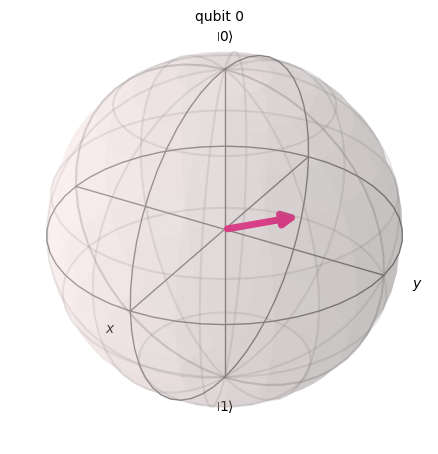

In [65]:
plot_bloch_multivector(sv)


(<Figure size 500x200 with 1 Axes>, <Axes: >)

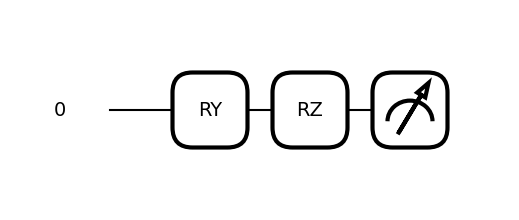

In [66]:
qml.draw_mpl(quantum_embedding)(theta, phi)